In [1]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print('Libraries loaded successfully')

/Users/shivamverma/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Libraries loaded successfully


In [2]:
base = os.path.join(
    os.path.expanduser('~'), 'Desktop',
    'Credit-Risk-Analytics-Portfolio',
    '01_scorecard_development'
)

train_woe = pd.read_csv(os.path.join(base, 'data', 'train_woe.csv'))
oot_woe   = pd.read_csv(os.path.join(base, 'data', 'oot_woe.csv'))

print('WOE datasets loaded')
print(f'Train shape : {train_woe.shape}')
print(f'OOT shape   : {oot_woe.shape}')
print(f'Train default rate : {train_woe["TARGET"].mean()*100:.2f}%')
print(f'OOT default rate   : {oot_woe["TARGET"].mean()*100:.2f}%')

WOE datasets loaded
Train shape : (246008, 12)
OOT shape   : (61503, 12)
Train default rate : 8.07%
OOT default rate   : 8.07%


In [3]:
feature_cols = [c for c in train_woe.columns if c != 'TARGET']

X_train = train_woe[feature_cols]
y_train = train_woe['TARGET']

X_oot = oot_woe[feature_cols]
y_oot = oot_woe['TARGET']

print(f'Feature columns : {len(feature_cols)}')
print(f'Features: {feature_cols}')

Feature columns : 11
Features: ['DAYS_LAST_PHONE_CHANGE_woe', 'DAYS_REGISTRATION_woe', 'EXT_SOURCE_3_woe', 'EMPLOYMENT_AGE_RATIO_woe', 'AGE_YEARS_woe', 'DAYS_ID_PUBLISH_woe', 'AMT_GOODS_PRICE_woe', 'EXT_SOURCE_2_woe', 'CREDIT_GOODS_RATIO_woe', 'AMT_CREDIT_woe', 'AMT_INCOME_TOTAL_woe']


In [4]:
X_vif = sm.add_constant(X_train)

vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_data = vif_data[vif_data['Feature'] != 'const']
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

def vif_status(vif):
    if vif < 5:    return 'Acceptable'
    elif vif < 10: return 'Review'
    else:          return 'High - Remove'

vif_data['Status'] = vif_data['VIF'].apply(vif_status)

print('VIF Analysis')
print('='*55)
print(vif_data.to_string(index=False))

VIF Analysis
                   Feature    VIF     Status
       AMT_GOODS_PRICE_woe 5.6592     Review
            AMT_CREDIT_woe 5.6357     Review
             AGE_YEARS_woe 1.4348 Acceptable
  EMPLOYMENT_AGE_RATIO_woe 1.2578 Acceptable
     DAYS_REGISTRATION_woe 1.1377 Acceptable
       DAYS_ID_PUBLISH_woe 1.1322 Acceptable
      AMT_INCOME_TOTAL_woe 1.0798 Acceptable
          EXT_SOURCE_2_woe 1.0677 Acceptable
          EXT_SOURCE_3_woe 1.0598 Acceptable
DAYS_LAST_PHONE_CHANGE_woe 1.0450 Acceptable
    CREDIT_GOODS_RATIO_woe 1.0441 Acceptable


In [5]:
# add_constant adds the intercept term to the model
X_train_sm = sm.add_constant(X_train)
X_oot_sm   = sm.add_constant(X_oot)

logit_model = sm.Logit(y_train, X_train_sm)
result      = logit_model.fit(maxiter=200, disp=False)

print('Logistic Regression Fitted')
print(f'Converged: {result.mle_retvals["converged"]}')

Logistic Regression Fitted
Converged: True


In [7]:
result.summary()



<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                 TARGET   No. Observations:               246008
Model:                          Logit   Df Residuals:                   245996
Method:                           MLE   Df Model:                           11
Date:                Sun, 15 Mar 2026   Pseudo R-squ.:                 0.08955
Time:                        19:10:25   Log-Likelihood:                -62836.
converged:                       True   LL-Null:                       -69017.
Covariance Type:            nonrobust   LLR p-value:                     0.000
==============================================================================================
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                         -2.4329      0.008   -303.166      0.000      -2.449      -2.417
DAYS_LAST_PHONE_CHANGE_woe     0.2486      0.040      6.219      0.000       0.170       0.327
DAYS_REGISTRATION_woe          0.2534      0.051      5.007      0.000       0.154       0.353
EXT_SOURCE_3_woe               0.8429      0.014     60.880      0.000       0.816       0.870
EMPLOYMENT_AGE_RATIO_woe       0.5512      0.029     18.855      0.000       0.494       0.609
AGE_YEARS_woe                  0.2194      0.031      7.112      0.000       0.159       0.280
DAYS_ID_PUBLISH_woe            0.1660      0.044      3.802      0.000       0.080       0.252
AMT_GOODS_PRICE_woe            0.3833      0.074      5.176      0.000       0.238       0.528
EXT_SOURCE_2_woe               0.8358      0.014     58.247      0.000       0.808       0.864
CREDIT_GOODS_RATIO_woe         0.7095      0.029     24.842      0.000       0.654       0.765
AMT_CREDIT_woe                 0.1365      0.076      1.803      0.071      -0.012       0.285
AMT_INCOME_TOTAL_woe           0.3625      0.077      4.696      0.000       0.211       0.514
==============================================================================================
"""

In [8]:
coef_df = pd.DataFrame({
    'Variable'   : result.params.index,
    'Coefficient': result.params.values,
    'Std_Error'  : result.bse.values,
    'z_score'    : result.tvalues.values,
    'p_value'    : result.pvalues.values,
    'CI_Lower'   : result.conf_int()[0].values,
    'CI_Upper'   : result.conf_int()[1].values
})

coef_df = coef_df[coef_df['Variable'] != 'const'].reset_index(drop=True)
coef_df = coef_df.sort_values('Coefficient', ascending=False)

coef_df['Sign_Check']  = coef_df['Coefficient'].apply(
    lambda x: 'Positive OK' if x > 0 else 'Negative - Investigate'
)
coef_df['Significant'] = coef_df['p_value'].apply(
    lambda x: 'Yes' if x < 0.05 else 'No'
)

print('Model Coefficients')
print('='*80)
print(coef_df[['Variable','Coefficient','p_value','Sign_Check','Significant']].to_string(index=False))

coef_df.to_csv(os.path.join(base, 'outputs', 'model_coefficients.csv'), index=False)
print('\nCoefficients saved')

Model Coefficients
                  Variable  Coefficient  p_value  Sign_Check Significant
          EXT_SOURCE_3_woe       0.8429   0.0000 Positive OK         Yes
          EXT_SOURCE_2_woe       0.8358   0.0000 Positive OK         Yes
    CREDIT_GOODS_RATIO_woe       0.7095   0.0000 Positive OK         Yes
  EMPLOYMENT_AGE_RATIO_woe       0.5512   0.0000 Positive OK         Yes
       AMT_GOODS_PRICE_woe       0.3833   0.0000 Positive OK         Yes
      AMT_INCOME_TOTAL_woe       0.3625   0.0000 Positive OK         Yes
     DAYS_REGISTRATION_woe       0.2534   0.0000 Positive OK         Yes
DAYS_LAST_PHONE_CHANGE_woe       0.2486   0.0000 Positive OK         Yes
             AGE_YEARS_woe       0.2194   0.0000 Positive OK         Yes
       DAYS_ID_PUBLISH_woe       0.1660   0.0001 Positive OK         Yes
            AMT_CREDIT_woe       0.1365   0.0714 Positive OK          No

Coefficients saved


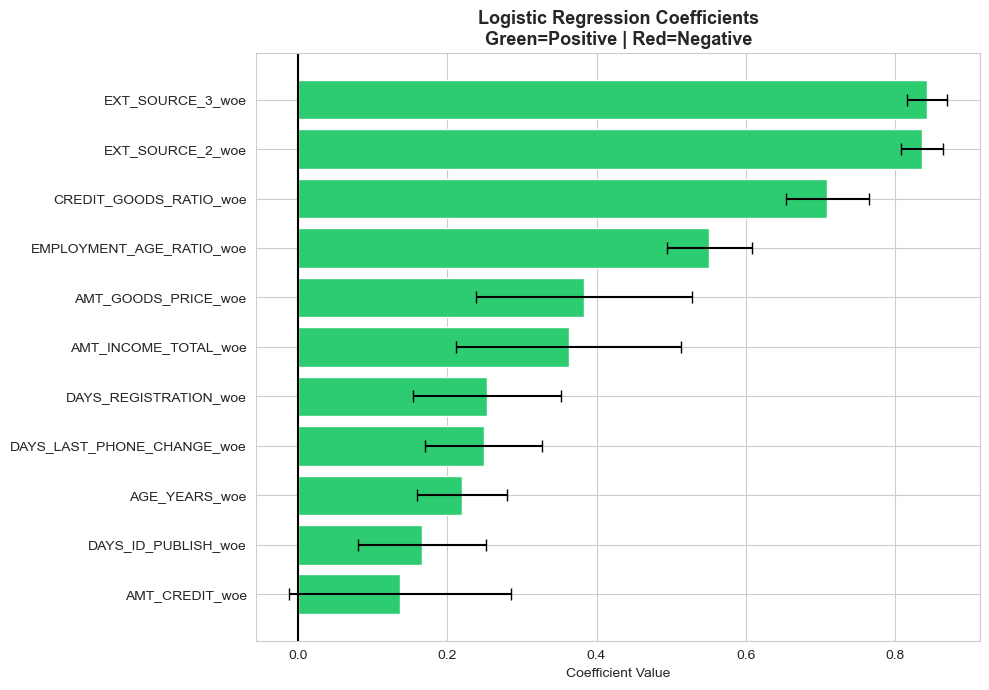

Chart saved


In [9]:
fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in coef_df['Coefficient']]
ax.barh(coef_df['Variable'], coef_df['Coefficient'], color=colors, edgecolor='white')

ax.errorbar(
    coef_df['Coefficient'],
    range(len(coef_df)),
    xerr=[
        coef_df['Coefficient'] - coef_df['CI_Lower'],
        coef_df['CI_Upper'] - coef_df['Coefficient']
    ],
    fmt='none', color='black', capsize=4, linewidth=1.5
)

ax.axvline(x=0, color='black', linewidth=1.5)
ax.set_title('Logistic Regression Coefficients\nGreen=Positive | Red=Negative',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient Value')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(base, 'outputs', '13_coefficients.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved')

In [10]:
train_prob = result.predict(X_train_sm)
oot_prob   = result.predict(X_oot_sm)

def calculate_metrics(y_true, y_prob, dataset_name):
    auroc = roc_auc_score(y_true, y_prob)
    gini  = 2 * auroc - 1
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    ks = max(tpr - fpr)

    print(f'\n{dataset_name} Performance')
    print('='*40)
    print(f'  AUROC : {auroc:.4f}')
    print(f'  Gini  : {gini:.4f}  ({gini*100:.1f}%)')
    print(f'  KS    : {ks:.4f}  ({ks*100:.1f}%)')
    print(f'  Gini benchmark >40%: {"PASS" if gini > 0.40 else "BELOW"}')
    print(f'  KS benchmark >30%  : {"PASS" if ks > 0.30 else "BELOW"}')

    return {'Dataset': dataset_name, 'AUROC': auroc, 'Gini': gini, 'KS': ks}

train_metrics = calculate_metrics(y_train, train_prob, 'TRAIN')
oot_metrics   = calculate_metrics(y_oot,   oot_prob,   'OOT')

gini_drop = train_metrics['Gini'] - oot_metrics['Gini']
print(f'\nGini Drop Train to OOT: {gini_drop:.4f}')
print(f'Stability: {"Stable - drop < 0.05" if gini_drop < 0.05 else "Review - drop >= 0.05"}')

metrics_df = pd.DataFrame([train_metrics, oot_metrics])
metrics_df.to_csv(os.path.join(base, 'outputs', 'model_performance.csv'), index=False)
print('\nMetrics saved')


TRAIN Performance
  AUROC : 0.7241
  Gini  : 0.4481  (44.8%)
  KS    : 0.3308  (33.1%)
  Gini benchmark >40%: PASS
  KS benchmark >30%  : PASS

OOT Performance
  AUROC : 0.7270
  Gini  : 0.4540  (45.4%)
  KS    : 0.3366  (33.7%)
  Gini benchmark >40%: PASS
  KS benchmark >30%  : PASS

Gini Drop Train to OOT: -0.0058
Stability: Stable - drop < 0.05

Metrics saved


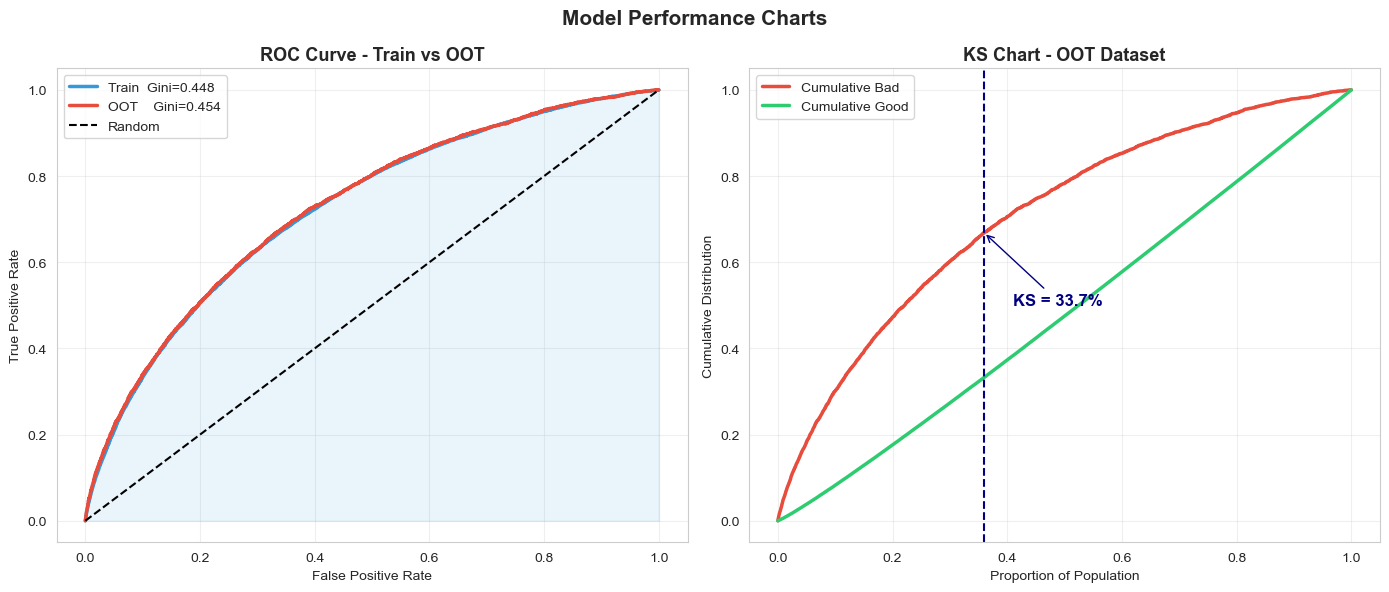

Charts saved


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

fpr_train, tpr_train, _ = roc_curve(y_train, train_prob)
fpr_oot,   tpr_oot,   _ = roc_curve(y_oot,   oot_prob)

# ROC Curve
axes[0].plot(fpr_train, tpr_train, color='#3498db', linewidth=2.5,
             label=f'Train  Gini={train_metrics["Gini"]:.3f}')
axes[0].plot(fpr_oot, tpr_oot, color='#e74c3c', linewidth=2.5,
             label=f'OOT    Gini={oot_metrics["Gini"]:.3f}')
axes[0].plot([0,1],[0,1],'k--',linewidth=1.5, label='Random')
axes[0].fill_between(fpr_train, tpr_train, alpha=0.1, color='#3498db')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve - Train vs OOT', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# KS Chart
oot_ks_df = pd.DataFrame({'prob': oot_prob, 'target': y_oot.values})
oot_ks_df = oot_ks_df.sort_values('prob', ascending=False).reset_index(drop=True)

total_bad  = oot_ks_df['target'].sum()
total_good = len(oot_ks_df) - total_bad

oot_ks_df['cum_bad']  = oot_ks_df['target'].cumsum() / total_bad
oot_ks_df['cum_good'] = (1 - oot_ks_df['target']).cumsum() / total_good
oot_ks_df['ks']       = oot_ks_df['cum_bad'] - oot_ks_df['cum_good']

ks_idx   = oot_ks_df['ks'].idxmax()
ks_value = oot_ks_df['ks'].max()
x_axis   = np.linspace(0, 1, len(oot_ks_df))

axes[1].plot(x_axis, oot_ks_df['cum_bad'],  color='#e74c3c',  linewidth=2.5, label='Cumulative Bad')
axes[1].plot(x_axis, oot_ks_df['cum_good'], color='#2ecc71', linewidth=2.5, label='Cumulative Good')

ks_x = ks_idx / len(oot_ks_df)
axes[1].axvline(x=ks_x, color='navy', linestyle='--', linewidth=1.5)
axes[1].annotate(f'KS = {ks_value*100:.1f}%',
                 xy=(ks_x, oot_ks_df.loc[ks_idx,'cum_bad']),
                 xytext=(ks_x+0.05, 0.5), fontsize=12, fontweight='bold', color='navy',
                 arrowprops=dict(arrowstyle='->', color='navy'))

axes[1].set_xlabel('Proportion of Population')
axes[1].set_ylabel('Cumulative Distribution')
axes[1].set_title('KS Chart - OOT Dataset', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Model Performance Charts', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(base, 'outputs', '14_roc_ks_charts.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Charts saved')

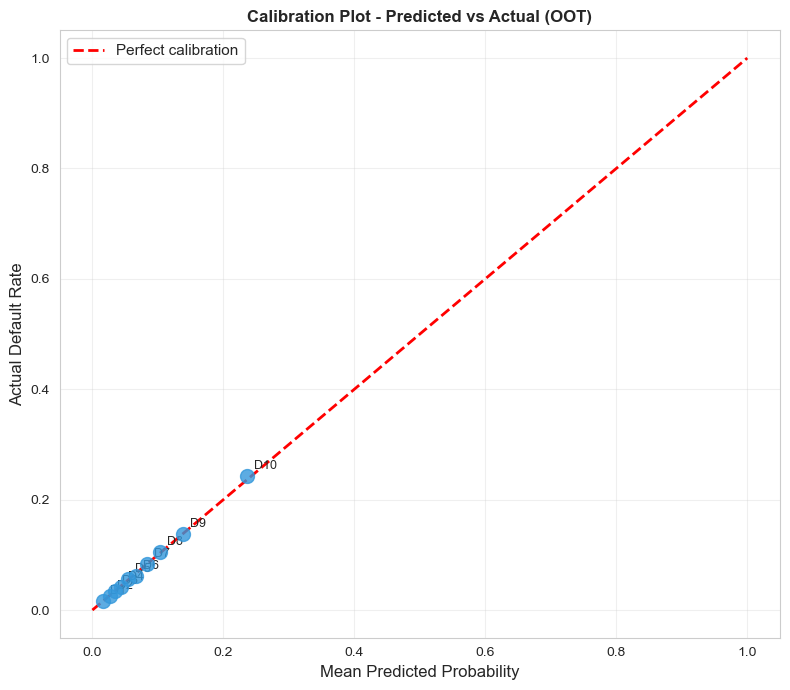

Calibration plot saved


In [12]:
calib_df = pd.DataFrame({'prob': oot_prob, 'actual': y_oot.values})
calib_df['decile'] = pd.qcut(calib_df['prob'], q=10, labels=False, duplicates='drop')

calib_summary = calib_df.groupby('decile').agg(
    mean_predicted=('prob',   'mean'),
    actual_rate   =('actual', 'mean'),
    count         =('actual', 'count')
).reset_index()

fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(calib_summary['mean_predicted'], calib_summary['actual_rate'],
           s=100, color='#3498db', alpha=0.8, zorder=5)
ax.plot([0,1],[0,1],'r--', linewidth=2, label='Perfect calibration')

for _, row in calib_summary.iterrows():
    ax.annotate(f'D{int(row["decile"])+1}',
                (row['mean_predicted'], row['actual_rate']),
                textcoords='offset points', xytext=(5,5), fontsize=9)

ax.set_xlabel('Mean Predicted Probability', fontsize=12)
ax.set_ylabel('Actual Default Rate', fontsize=12)
ax.set_title('Calibration Plot - Predicted vs Actual (OOT)', fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(base, 'outputs', '15_calibration_plot.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Calibration plot saved')

In [13]:
decile_df = pd.DataFrame({'prob': oot_prob, 'actual': y_oot.values})
decile_df = decile_df.sort_values('prob', ascending=False).reset_index(drop=True)
decile_df['decile'] = pd.qcut(decile_df.index, q=10,
                               labels=[f'D{i}' for i in range(1, 11)])

overall_dr = decile_df['actual'].mean()

decile_summary = decile_df.groupby('decile', observed=True).agg(
    Count       =('actual', 'count'),
    Defaults    =('actual', 'sum'),
    Default_Rate=('actual', 'mean'),
    Mean_Score  =('prob',   'mean')
).reset_index()

decile_summary['Lift']          = (decile_summary['Default_Rate'] / overall_dr).round(2)
decile_summary['Default_Rate_%']= (decile_summary['Default_Rate'] * 100).round(2)
decile_summary['Cum_Bad_%']     = (decile_summary['Defaults'].cumsum() /
                                    decile_summary['Defaults'].sum() * 100).round(1)

print('Decile Analysis (OOT)')
print('='*65)
print(decile_summary[['decile','Count','Defaults','Default_Rate_%','Lift','Cum_Bad_%']].to_string(index=False))
print(f'\nOverall Default Rate : {overall_dr*100:.2f}%')
print(f'Top Decile Lift      : {decile_summary.iloc[0]["Lift"]:.2f}x')
print(f'Top 3 Deciles capture: {decile_summary.iloc[:3]["Cum_Bad_%"].max():.1f}% of all defaults')

Decile Analysis (OOT)
decile  Count  Defaults  Default_Rate_%   Lift  Cum_Bad_%
    D1   6151      1494         24.2900 3.0100    30.1000
    D2   6150       851         13.8400 1.7100    47.2000
    D3   6150       643         10.4600 1.3000    60.2000
    D4   6150       515          8.3700 1.0400    70.6000
    D5   6151       384          6.2400 0.7700    78.3000
    D6   6150       347          5.6400 0.7000    85.3000
    D7   6150       252          4.1000 0.5100    90.4000
    D8   6150       215          3.5000 0.4300    94.7000
    D9   6150       161          2.6200 0.3200    97.9000
   D10   6151       103          1.6700 0.2100   100.0000

Overall Default Rate : 8.07%
Top Decile Lift      : 3.01x
Top 3 Deciles capture: 60.2% of all defaults


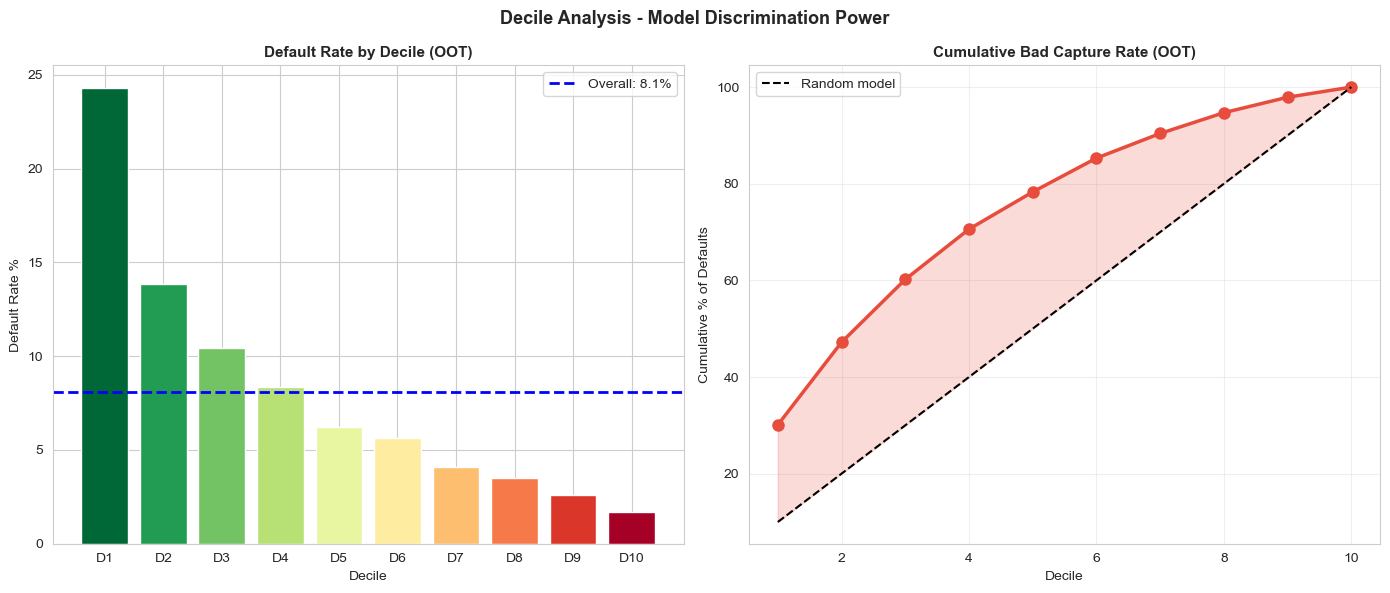

Decile chart saved


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors_d = plt.cm.RdYlGn_r(np.linspace(0, 1, len(decile_summary)))
axes[0].bar(decile_summary['decile'], decile_summary['Default_Rate_%'],
            color=colors_d, edgecolor='white')
axes[0].axhline(y=overall_dr*100, color='blue', linestyle='--', linewidth=2,
                label=f'Overall: {overall_dr*100:.1f}%')
axes[0].set_title('Default Rate by Decile (OOT)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Decile')
axes[0].set_ylabel('Default Rate %')
axes[0].legend()

axes[1].plot(range(1,11), decile_summary['Cum_Bad_%'],
             'o-', color='#e74c3c', linewidth=2.5, markersize=8)
axes[1].plot(range(1,11), np.linspace(10,100,10),
             'k--', linewidth=1.5, label='Random model')
axes[1].fill_between(range(1,11), decile_summary['Cum_Bad_%'],
                     np.linspace(10,100,10), alpha=0.2, color='#e74c3c')
axes[1].set_title('Cumulative Bad Capture Rate (OOT)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Decile')
axes[1].set_ylabel('Cumulative % of Defaults')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Decile Analysis - Model Discrimination Power', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(base, 'outputs', '16_decile_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Decile chart saved')

In [15]:
train_scored = X_train.copy()
train_scored['TARGET']    = y_train.values
train_scored['PRED_PROB'] = train_prob
train_scored['LOG_ODDS']  = np.log(train_prob / (1 - train_prob + 1e-10))

oot_scored = X_oot.copy()
oot_scored['TARGET']    = y_oot.values
oot_scored['PRED_PROB'] = oot_prob
oot_scored['LOG_ODDS']  = np.log(oot_prob / (1 - oot_prob + 1e-10))

train_scored.to_csv(os.path.join(base, 'outputs', 'train_scored.csv'), index=False)
oot_scored.to_csv(os.path.join(base, 'outputs', 'oot_scored.csv'),   index=False)

print('Scored datasets saved')
print(f'train_scored.csv: {train_scored.shape}')
print(f'oot_scored.csv  : {oot_scored.shape}')

Scored datasets saved
train_scored.csv: (246008, 14)
oot_scored.csv  : (61503, 14)


In [ ]:
print('='*60)
print('  LOGISTIC REGRESSION SCORECARD - SUMMARY')
print('='*60)
print(f'Features used      : {len(feature_cols)}')
print(f'Training records   : {len(X_train):,}')
print(f'OOT records        : {len(X_oot):,}')
print()
print('TRAIN PERFORMANCE')
print(f'  Gini  : {train_metrics["Gini"]*100:.1f}%')
print(f'  KS    : {train_metrics["KS"]*100:.1f}%')
print(f'  AUROC : {train_metrics["AUROC"]:.4f}')
print()
print('OOT PERFORMANCE')
print(f'  Gini  : {oot_metrics["Gini"]*100:.1f}%')
print(f'  KS    : {oot_metrics["KS"]*100:.1f}%')
print(f'  AUROC : {oot_metrics["AUROC"]:.4f}')
print()
print(f'Gini Drop          : {(train_metrics["Gini"]-oot_metrics["Gini"])*100:.1f}%')
print(f'Top Decile Lift    : {decile_summary.iloc[0]["Lift"]:.2f}x')
print()
print('OUTPUTS SAVED')
print('  model_coefficients.csv')
print('  model_performance.csv')
print('  train_scored.csv')
print('  oot_scored.csv')
print('  13_coefficients.png')
print('  14_roc_ks_charts.png')
print('  15_calibration_plot.png')
print('  16_decile_analysis.png')
print()
print('NEXT: 05_model_validation.ipynb')
print('='*60)